# Jotting Down

This notebook represents an exploration of writing patterns inspired by note-taking during reading. By simulating the intuitive, it captures the creative process of expression while we read.
        

In [1]:
import sys
!{sys.executable} -m pip install git+https://github.com/aparrish/vsketch

  Cloning https://github.com/aparrish/vsketch to /private/var/folders/x9/9jxql1vx7pq2hspk458v48x40000gn/T/pip-req-build-kyc__xr8
  Running command git clone --filter=blob:none --quiet https://github.com/aparrish/vsketch /private/var/folders/x9/9jxql1vx7pq2hspk458v48x40000gn/T/pip-req-build-kyc__xr8
  Resolved https://github.com/aparrish/vsketch to commit 852a0aa516fe021e230e277de1b3ca8314cbb10b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/abey79/vpype/ (to revision master) to /private/var/folders/x9/9jxql1vx7pq2hspk458v48x40000gn/T/pip-install-cftty9vk/vpype_4a9eb0fbe984467e8c04f5807dc62118
  Running command git clone --filter=blob:none --quiet https://github.com/abey79/vpype/ /private/var/folders/x9/9jxql1vx7pq2hspk458v48x40000gn/T/pip-install-cftty9vk/vpype_4a9eb0fbe984467e8c04f5807dc62118
  Resolved https://github.com/abey79/vpype/ to commit 3dbc352d3e4f37c20ff3d28e

In [2]:
import sys
!{sys.executable} -m pip install --upgrade https://github.com/aparrish/bezmerizing/archive/main.zip

  Using cached https://github.com/aparrish/bezmerizing/archive/main.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import random
import vsketch
import bezmerizing

In [34]:
from math import sin, cos, radians
from numpy.random import randint

In [35]:
from numpy.random import uniform, normal, choice
import numpy as np

In [36]:
from scipy.stats import truncnorm
def t_normal(a, b, mu, sigma):
    tn = truncnorm((a-mu)/sigma, (b-mu)/sigma, loc=mu, scale=sigma)
    return tn.rvs(1)[0]

In [37]:
def uniform_glyph_baseline(n=10):
    pts = [[-0.4, 0.5], [0.4, 0.5]]
    for i in range(n):
        pts.append([uniform(-0.5, 0.5), uniform(-0.5, 0.5)])
    return pts

In [38]:
glyph_count = 100
glyph_widths = [choice([0.2, 0.333, 0.667, 1], p=[0.1, 0.5, 0.3, 0.1]) for i in range(glyph_count)]
glyph_widths[:12]

[np.float64(0.667),
 np.float64(0.667),
 np.float64(0.2),
 np.float64(0.333),
 np.float64(0.333),
 np.float64(0.333),
 np.float64(0.333),
 np.float64(0.2),
 np.float64(0.333),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.667)]

In [39]:
def baseline_glyph_varwidth(n=10, width=1.0):
    pts = [[0, 0], [width, 0]]
    for i in range(n):
        pts.append([uniform(0, width), uniform(0, -1)])
    return pts

In [40]:
def grid_glyph():
    pts = []
    for i in range(int(t_normal(4, 12, 8, 2))):
        x = (choice([-0.5, 0, 0.5]))
        y = (choice([-0.5, 0, 0.5]))
        pts.append([x, y])
    return pts

In [41]:
import sys
import random
import vsketch
import bezmerizing
import numpy as np
from numpy.random import uniform, normal, choice
from scipy.stats import truncnorm
import math

In [42]:
def t_normal(a, b, mu, sigma):
    tn = truncnorm((a-mu)/sigma, (b-mu)/sigma, loc=mu, scale=sigma)
    return tn.rvs(1)[0]

create canvas

In [43]:
width = 210 
height = 297 
margin = 8
vsk = vsketch.Vsketch()
vsk.size(f"{width}mm", f"{height}mm")
vsk.scale("1mm")

function to generate handwritten character

In [44]:
def handwritten_char(width_factor=0.8, height_factor=1.0, complexity=None):
    if complexity is None:
        complexity = int(t_normal(3, 8, 5, 1.5))
    pts = []
    pts.append([0, 0])
    
    # add random points
    for i in range(complexity):
        x = uniform(0, width_factor)
        y = uniform(-height_factor, 0) if i % 2 == 0 else uniform(0, height_factor * 0.3)
        pts.append([x, y])
    
    # humanize a bit
    for i in range(1, len(pts)):
        pts[i][0] += uniform(-0.05, 0.05)
        pts[i][1] += uniform(-0.05, 0.05)
    
    # create smooth curves
    smooth = (
        bezmerizing.Polyline(pts)
        .augment()
        .catmull_spline(tightness=uniform(-0.6, -0.2))
        .to_polyline(10)
    )
    
    return smooth, width_factor

function to draw handwritten words

In [45]:
def draw_handwritten_word(vsk, x, y, chars_count, char_width=4, char_height=6, spacing=0.8):
    current_x = x
    
    for i in range(chars_count):
        # randomize character width slightly
        width_factor = uniform(0.3, 0.7)
        height_factor = uniform(0.3, 0.6)
        
        char, width = handwritten_char(width_factor, height_factor)
        
        with vsk.pushMatrix():
            vsk.translate(current_x, y)
            vsk.scale(char_width, char_height)
            # slightly randomize rotation
            vsk.rotate(uniform(-0.05, 0.05))
            vsk.polygon(char)
        
        current_x += char_width * width_factor * spacing + uniform(0, 0.5)
    
    return current_x - x

Function to create a random underline

In [46]:
def draw_underline(vsk, x, y, length, waviness=0.5):
    pts = []
    num_points = int(length / 5) + 2
    
    for i in range(num_points):
        pos_x = x + (i * length / (num_points - 1))
        pos_y = y + uniform(-waviness, waviness)
        pts.append([pos_x, pos_y])
    
    smooth = (
        bezmerizing.Polyline(pts)
        .augment()
        .catmull_spline(tightness=-0.25)
        .to_polyline(int(length / 2))
    )
    
    vsk.polygon(smooth)

Function to create a circled annotation

In [47]:
def draw_circle(vsk, center_x, center_y, radius_x, radius_y=None, irregularity=0.8):
    if radius_y is None:
        radius_y = radius_x
    
    # create points on the circle
    num_points = int(t_normal(15, 30, 20, 5))
    pts = []
    
    for i in range(num_points):
        angle = 2 * math.pi * i / num_points
        # add randomness
        r_x = radius_x * (1 + uniform(-irregularity/2, irregularity/2) * 0.2)
        r_y = radius_y * (1 + uniform(-irregularity/2, irregularity/2) * 0.2)
        
        x = center_x + r_x * math.cos(angle)
        y = center_y + r_y * math.sin(angle)
        
        # slight imperfection
        x += uniform(-irregularity, irregularity)
        y += uniform(-irregularity, irregularity)
        
        pts.append([x, y])
    
    pts.append(pts[0])
    
    # create smooth curves
    smooth = (
        bezmerizing.Polyline(pts)
        .augment()
        .catmull_spline(tightness=t_normal(-0.5, -0.1, -0.3, 0.1))
        .to_polyline(6)
    )
    
    vsk.polygon(smooth)

Function to create a curved bracket in the margin

In [48]:
def draw_bracket(vsk, x, y, height, right_facing=False, curvature=0.3):
    num_points = int(height / 5) + 2
    pts = []
    
    for i in range(num_points):
        pos_y = y + (i * height / (num_points - 1))
        curve_factor = i / (num_points - 1)  #0 to 1
        curve_amount = math.sin(curve_factor * math.pi) * curvature
        
        if right_facing:
            pos_x = x - curve_amount * 10
        else:
            pos_x = x + curve_amount * 10
            
        pos_x += uniform(-0.3, 0.3)
        pos_y += uniform(-0.3, 0.3)
        
        pts.append([pos_x, pos_y])
    
    smooth = (
        bezmerizing.Polyline(pts)
        .augment()
        .catmull_spline(tightness=-0.25)
        .to_polyline(int(height * 2))
    )
    
    vsk.polygon(smooth)

Function to create a squiggly line (for emphasis)

In [49]:
def draw_squiggle(vsk, x, y, length, amplitude=2, frequency=0.2):
    pts = []
    num_points = int(length / 2) + 2
    
    for i in range(num_points):
        pos_x = x + (i * length / (num_points - 1))
        # create a wave
        pos_y = y + math.sin(i * frequency * math.pi) * amplitude
        pos_y += uniform(-0.5, 0.5)
        
        pts.append([pos_x, pos_y])
    
    # create smooth curves
    smooth = (
        bezmerizing.Polyline(pts)
        .augment()
        .catmull_spline(tightness=-0.3)
        .to_polyline(int(length * 2))
    )
    
    vsk.polygon(smooth)

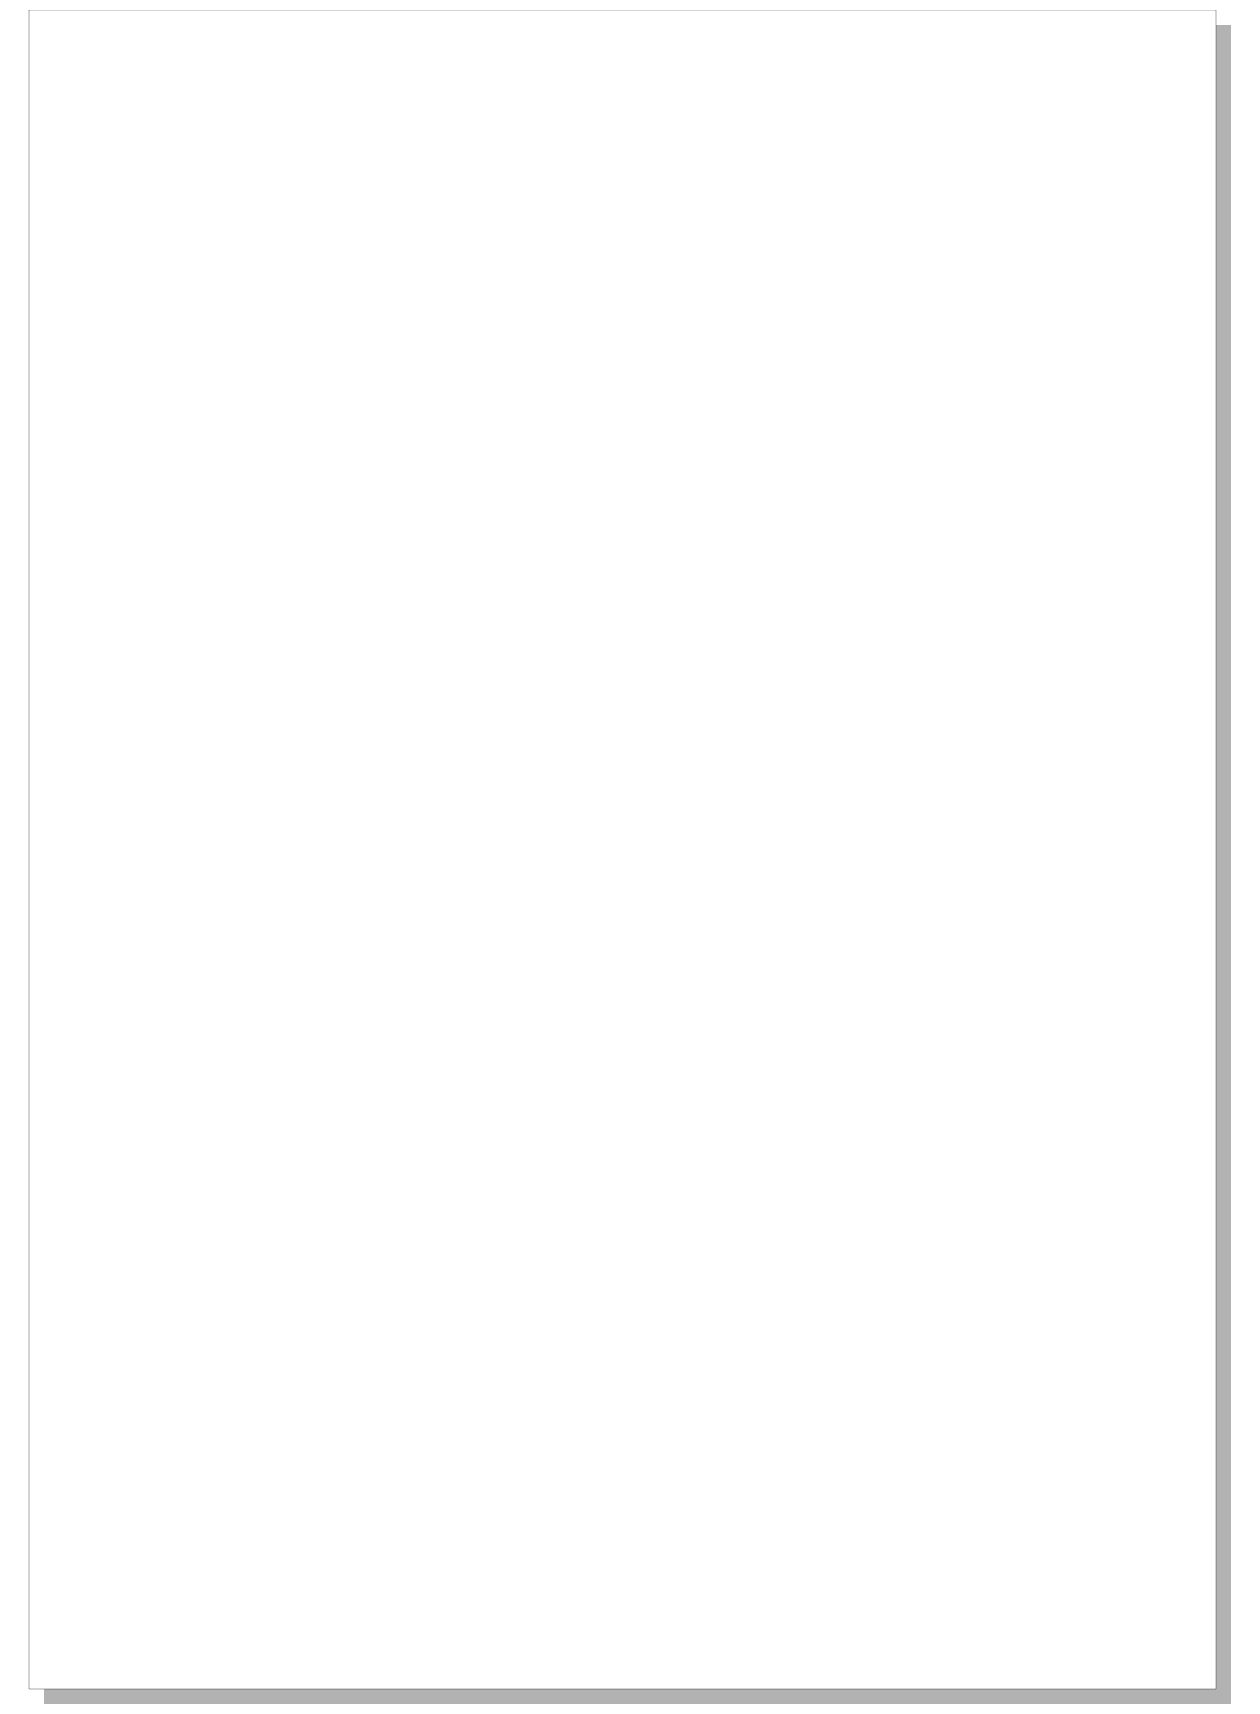

In [20]:
vsk.display(fig_size=(16, 22))

Add some underlines

In [21]:
for _ in range(4):
    # choose random position for underline
    x = margin + 15 + uniform(0, width - 2*margin - 80)
    y = margin + 30 + uniform(10, height - 2*margin - 50)
    length = uniform(30, 80)
    
    vsk.stroke(2)
    draw_underline(vsk, x, y, length, waviness=0.8)

Add some circles around "words"

In [22]:
for _ in range(3):
    x = margin + 40 + uniform(0, width - 2 * margin - 100)
    y = margin + 12 + uniform(20, height - 2 * margin - 70)
    rx = uniform(10, 25)
    ry = uniform(2, 4)
    
    vsk.stroke(1)
    draw_circle(vsk, x, y, rx, ry)

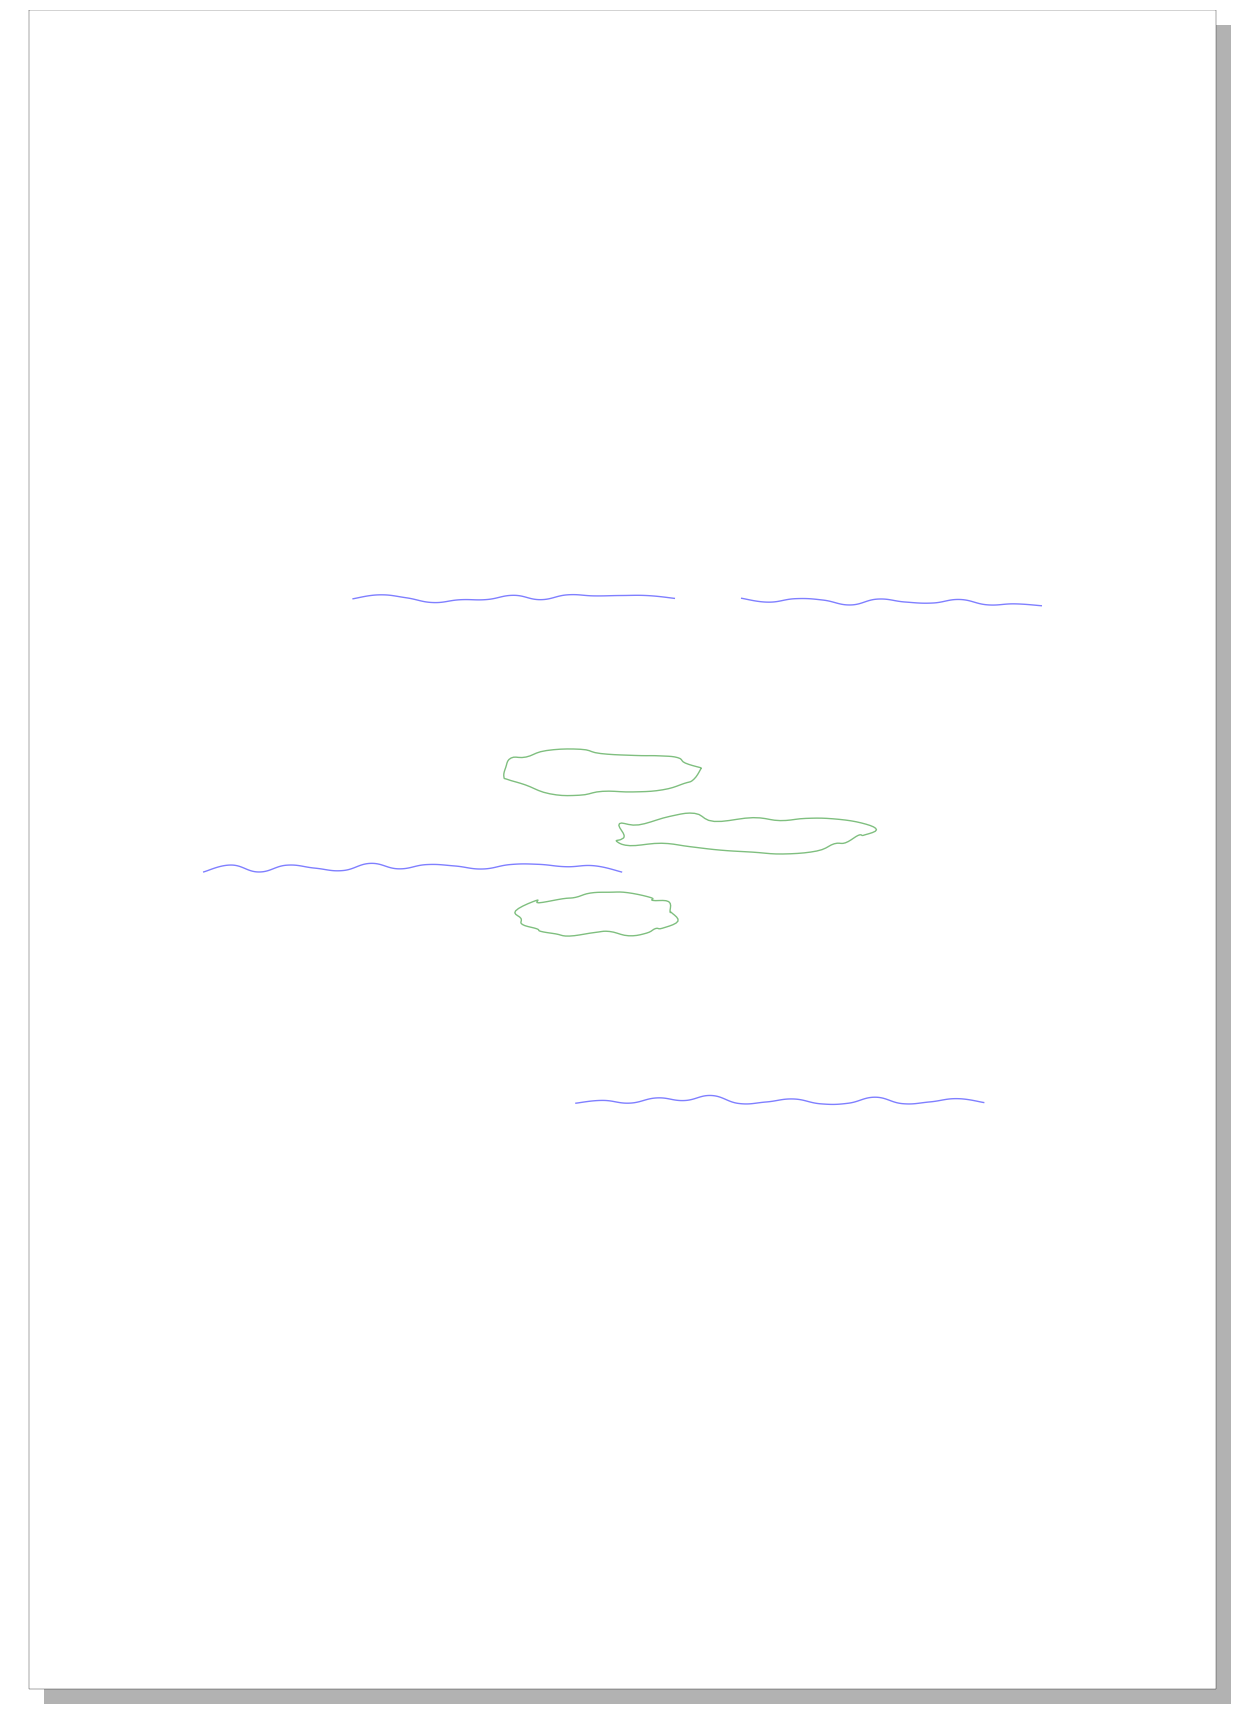

In [23]:
vsk.display(fig_size=(16, 22))

Add margin notes

In [50]:
right_margin_x = width - margin - 40
for _ in range(20):
    y = margin + 40 + uniform(0, height - 2 *margin - 80)
    word_length = random.randint(8, 12)
    
    vsk.stroke(1)
    draw_handwritten_word(vsk, right_margin_x, y, word_length)

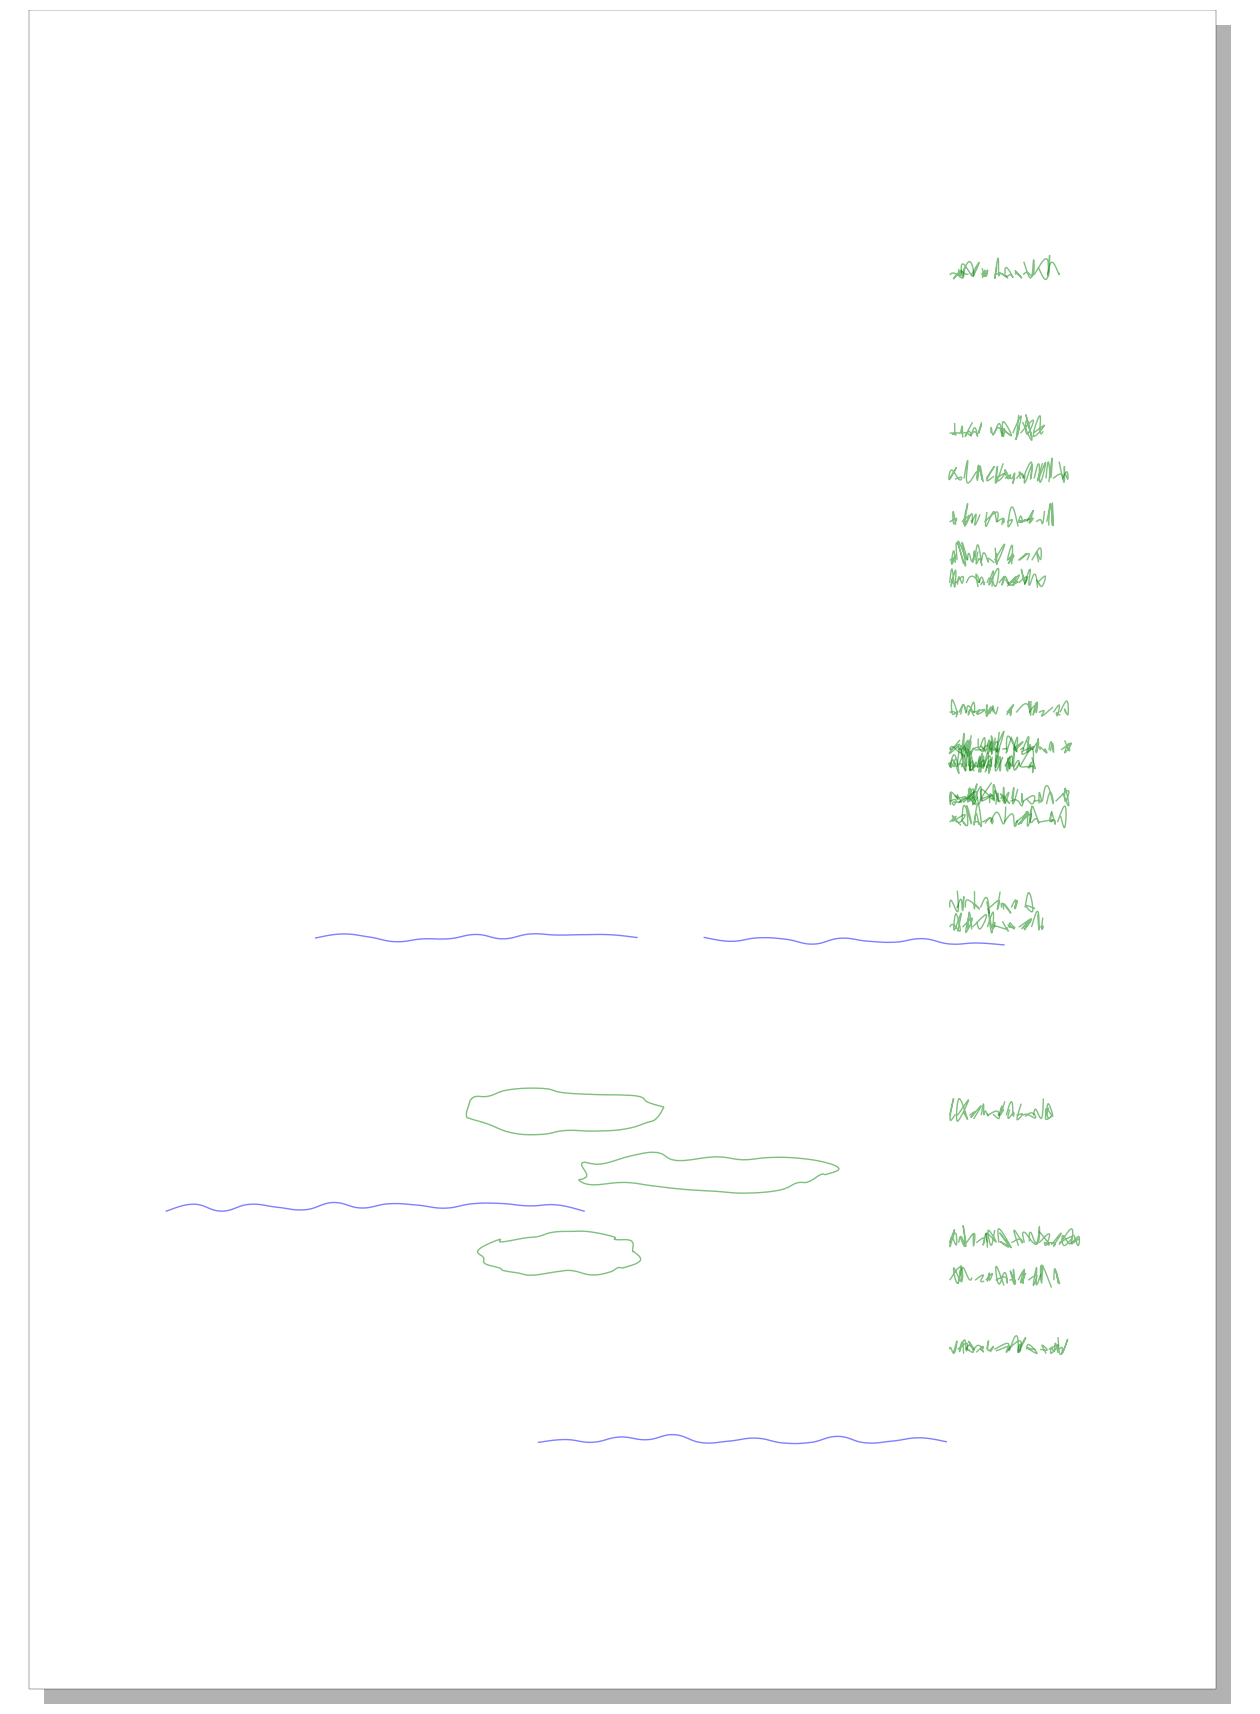

In [25]:
vsk.display(fig_size=(16, 22))

Add brackets in margins

In [26]:
for _ in range(2):
    x = margin + 5
    y = margin + 50 + uniform(0, height - 2*margin - 100)
    bracket_height = uniform(20, 50)
    
    vsk.stroke(1)
    draw_bracket(vsk, x, y, bracket_height)

Add squiggly emphasis lines

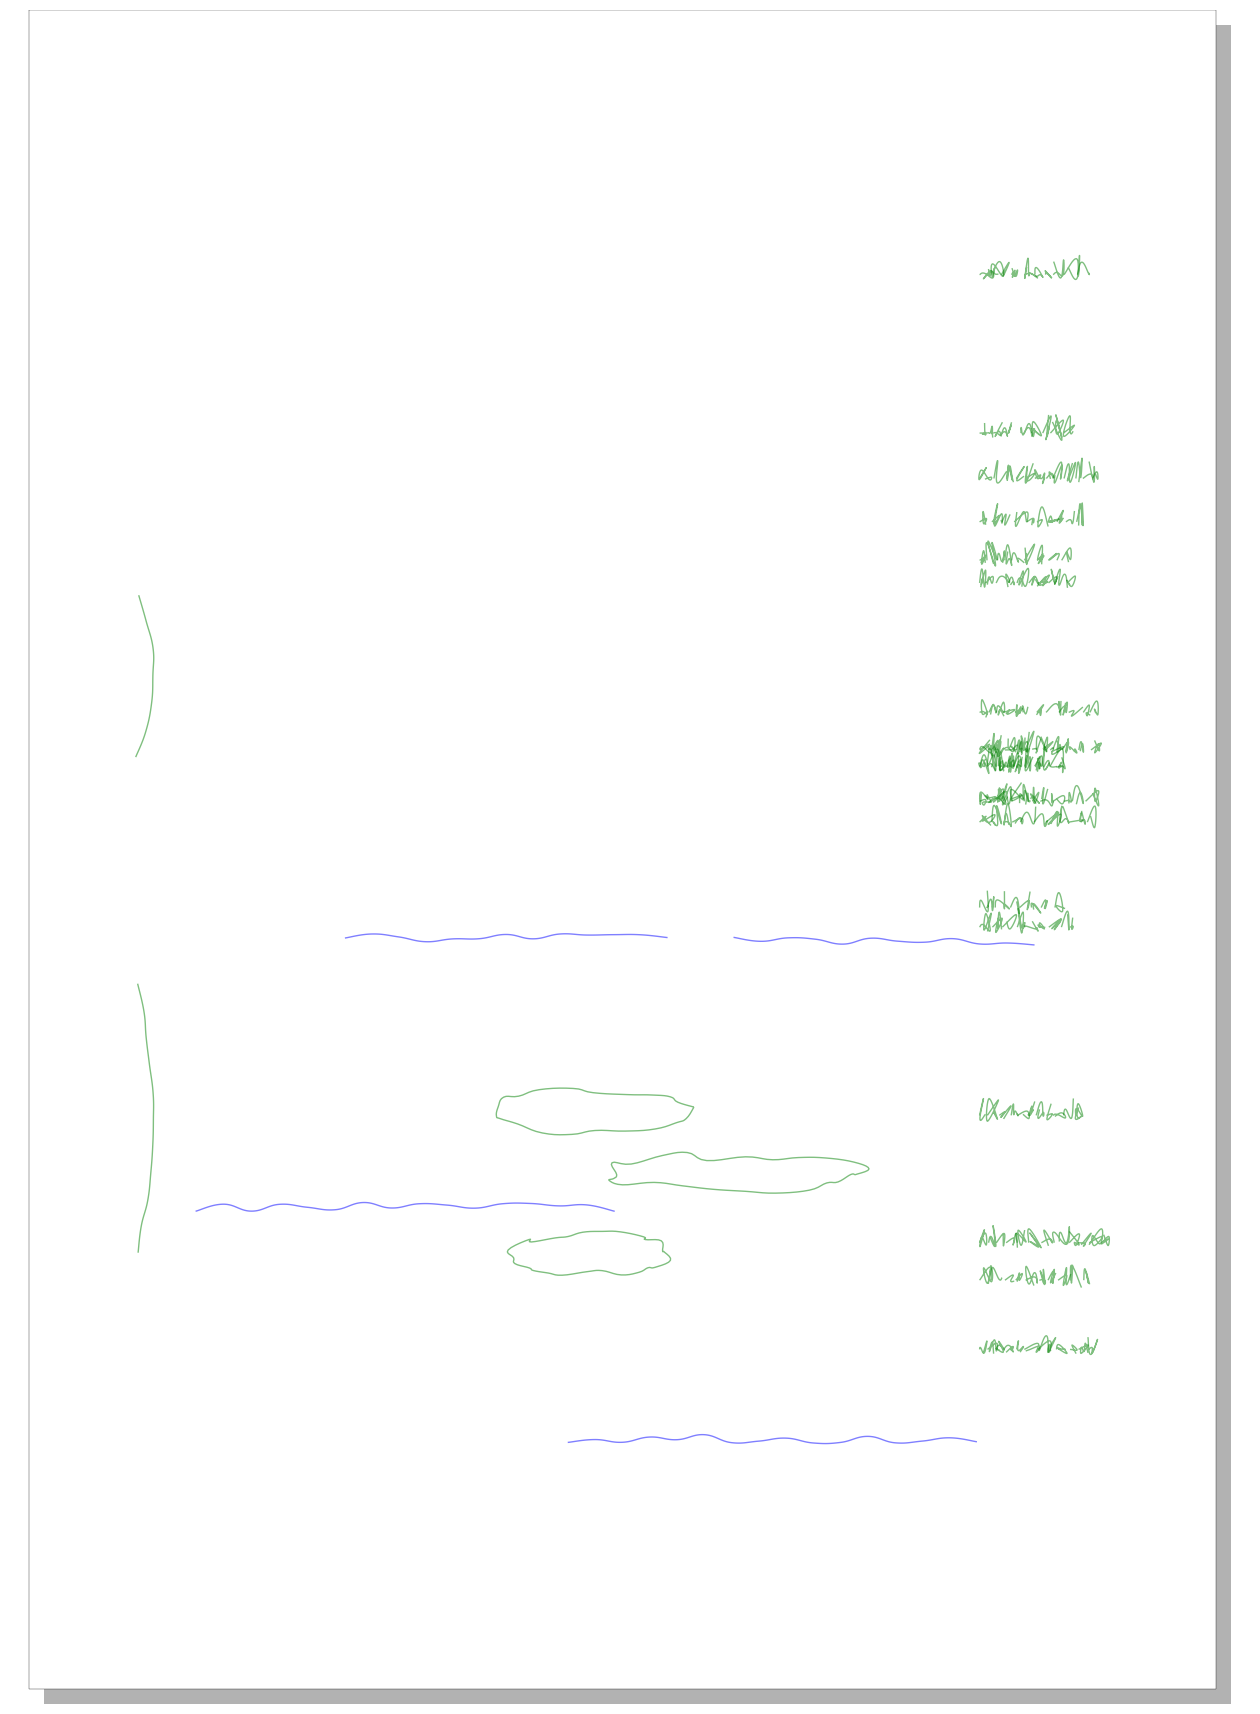

In [27]:
vsk.display(fig_size=(16, 22))

In [52]:
for _ in range(3):
    x = margin + 20 + uniform(0, width - 2*margin - 90)
    y = margin + 40 + uniform(0, height - 2*margin - 80)
    length = uniform(20, 60)
    
    vsk.stroke(1)
    draw_squiggle(vsk, x, y, length)

Add exclamation points in margins

In [51]:
for _ in range(2):
    x = width - margin - 15
    y = margin + 60 + uniform(0, height - 2*margin - 120)
    
    vsk.line(x, y - 5, x, y - 1)
    vsk.ellipse(x, y, 0.5, 0.5)

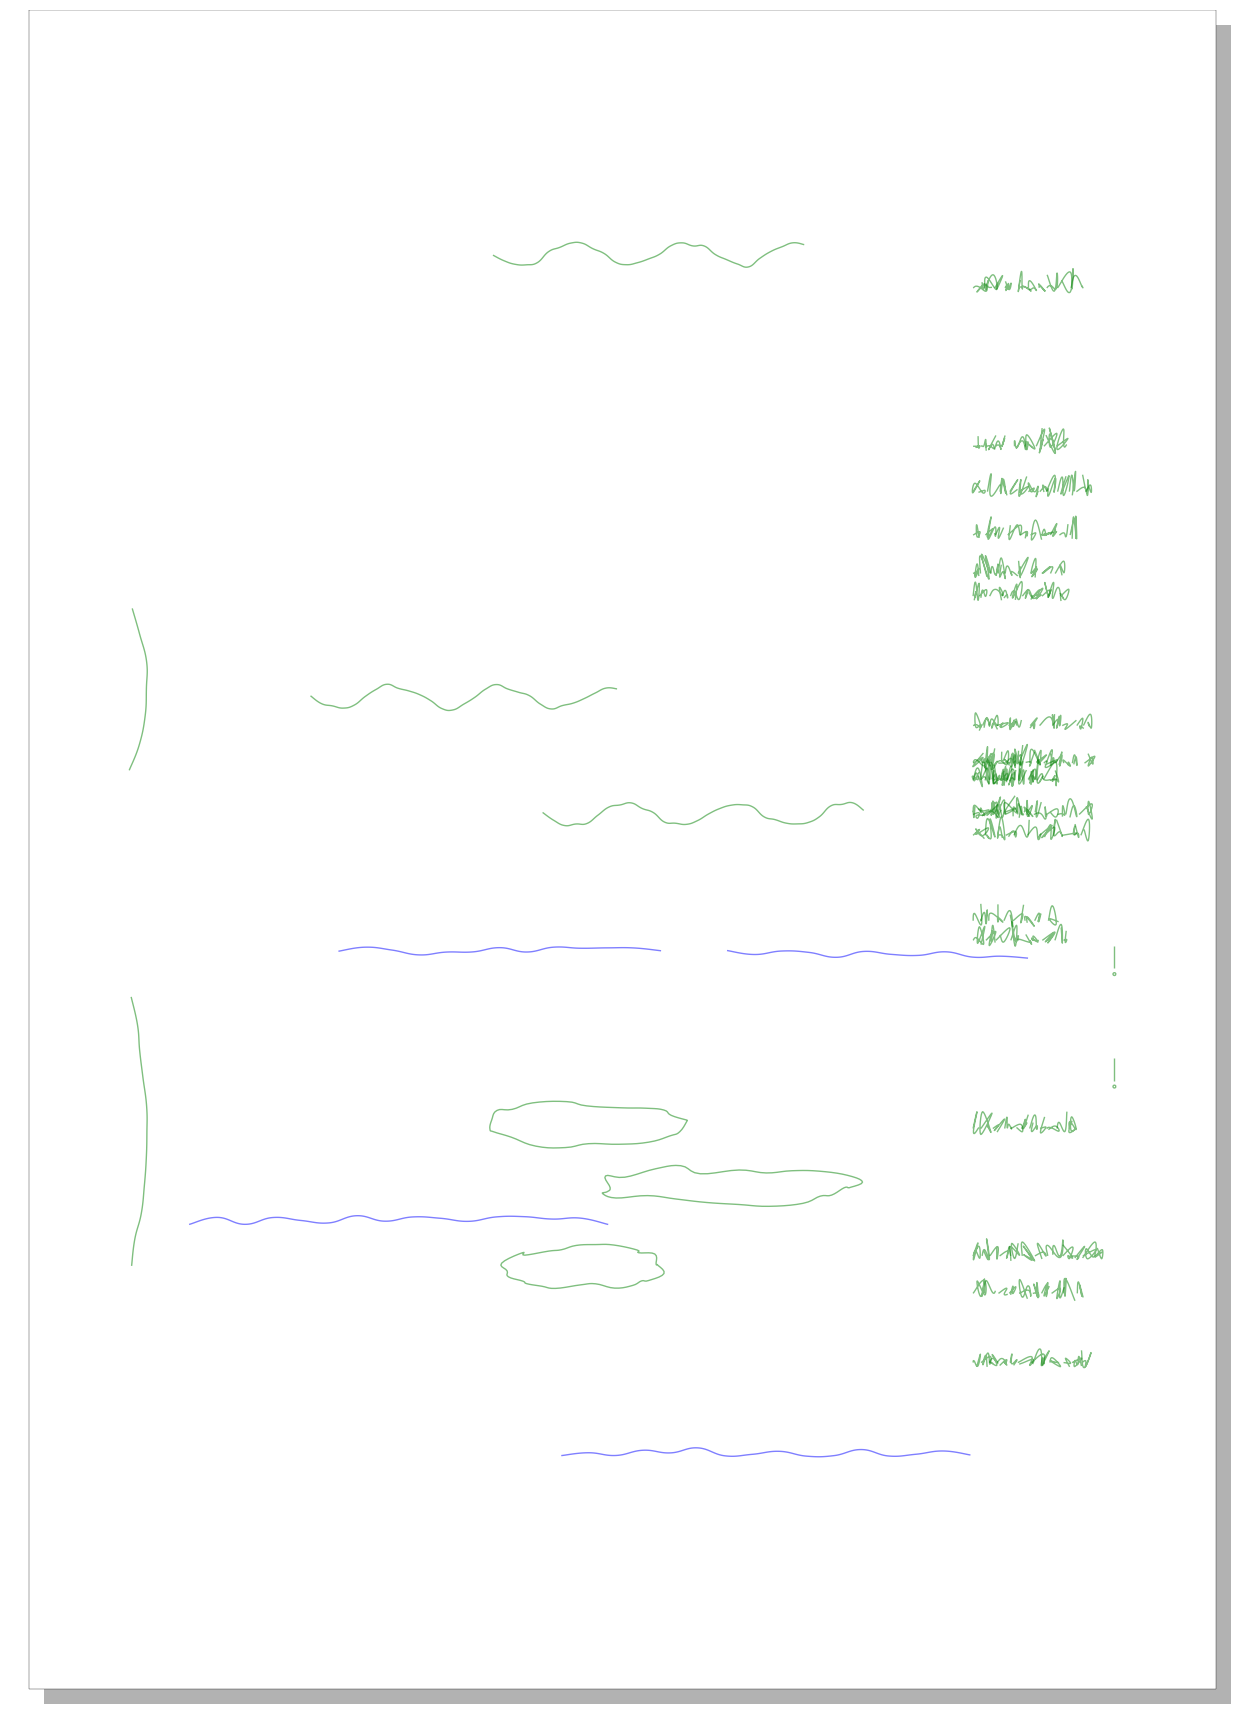

In [30]:
vsk.display(fig_size=(16, 22))

Add more detailed notes at the bottom of the page

In [53]:
bottom_note_y = height - margin - 30
bottom_note_x = margin + 30

Add handwritten circles in a few places (more circular than the previous ones)

In [32]:
for _ in range(2):
    x = margin + 40 + uniform(0, width - 2*margin - 100)
    y = margin + 10 + uniform(0, height - 2*margin - 100)
    radius = uniform(8, 10)
    vsk.stroke(1)
    draw_circle(vsk, x, y, 4, 1, irregularity=0.2)

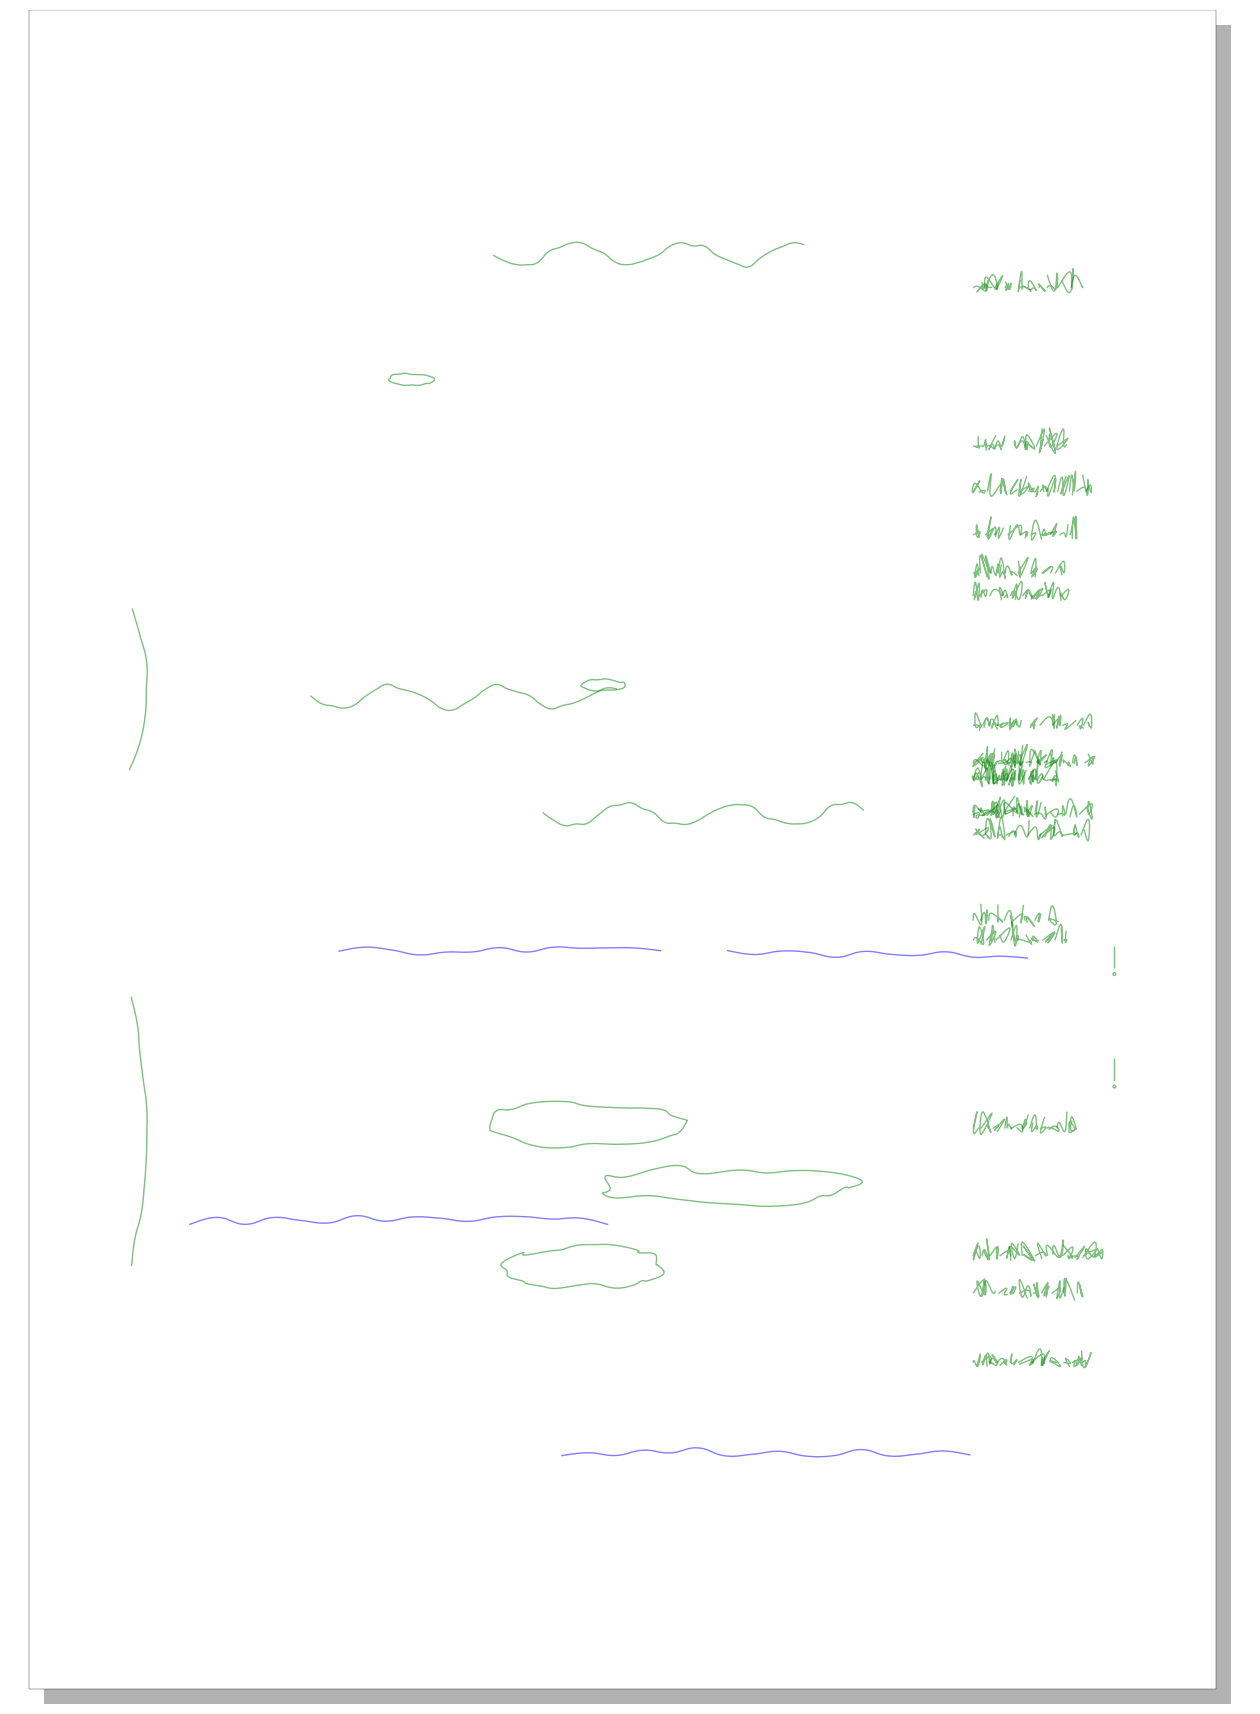

In [33]:
vsk.display(fig_size=(16, 22))